# Unsupervised clustering

Here we are given a csv file, and we need to organise it in a human-like way.

This csv is composed of people describing their symptoms. Theoretically, we should be able to roughly place them in a category of disease.

Here is a nice tutorial explaining how to cluster text: [tutorial_link](https://www.geeksforgeeks.org/machine-learning/clustering-text-documents-using-k-means-in-scikit-learn/)


### list of chages to make it more accurate:
- changed the PCA to 100 components, because 2 components is not enough to capture the variance in the data, it was only for visualization purposes.
  - this makes it very much more precise, but it becomes very difficult to visualise in a matplotlib plot, so well have to figure a way to visualise it, maybe with a t-SNE plot or something like that.
- I also realised that i don't actually know how many clusters to use , we use a silhouette score to find the optimal number of clusters, and then use that number of clusters for the KMeans algorithm.
    - Howver, it keeps telling me that i should just increase the number of clusters, so i printed what the what the vectoring thinks are the most important words, and it seems that its just putting the same kind of injury on different spots of the body.

In [113]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

Now we will obtain our csv file, and we will obtain the data from it with pandas.

We will then use the TfidfVectorizer to transform the text into a vector that we can use for clustering.
What TfidfVectorizer does is that it gives a weight to each word in the text, based on how often it appears in the document and how often it appears in the entire corpus. This way, we can give more importance to words that are unique to a document, and less importance to words that are common across all documents. (this is to remove stop words like "the", "is", etc.)


In [114]:
df = pd.read_csv("../rsrc/Student_Dataset_Clean.csv")

symptom_texts = df['DiseaseSymptom'].tolist() #we will use the "DiseaseSymptom" column as our text data for clustering

vectoriser = TfidfVectorizer(stop_words='english') #specifies that language is english, so it will remove stop words like "the", "is", etc.

vectorised_symptoms = vectoriser.fit_transform(symptom_texts) #fit_transform will learn the vocabulary and idf from the training set, and return the term-document matrix

We will now use PCA to reduce the dimensionality of the data, and KMeans to cluster the data.

But what is PCA? Essentially, TfidfVectorizer will give us a very high-dimensional vector (one dimension for each word in the text), and PCA will help us reduce this dimensionality while preserving as much of the variance in the data as possible. This way, we can visualize the data in 2D or 3D, and it will also help KMeans to cluster the data better.


In [115]:
pca = PCA(n_components=100) #we will reduce the dimensionality to 100 for visualization purposes
reduced_symptoms = pca.fit_transform(vectorised_symptoms.toarray()) #fit_transform will learn the PCA model and apply the dimensionality reduction to the data

We will now use a silhouette score to find the optimal number of clusters.

A silhouette score is a measure of how well a data point fits into its assigned cluster, compared to other clusters. It ranges from -1 to 1, where a score of 1 means that the data point is well matched to its own cluster and poorly matched to neighboring clusters, a score of 0 means that the data point is on or very close to the decision boundary between two neighboring clusters, and a score of -1 means that the data point is misclassified and assigned to the wrong cluster.

In [116]:
from sklearn.metrics import silhouette_score
best_k = 0
best_score = -1
for k in range(4, 20):
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=1000, n_init=100)
    labels = kmeans.fit_predict(vectorised_symptoms)

    score = silhouette_score(vectorised_symptoms, labels)
    if score > best_score:
        best_score = score
        best_k = k
    print(k, score)

print(f"Best number of clusters: {best_k}")




4 0.010936242365892393
5 0.014089279355477838
6 0.015146407420400958
7 0.016410741834252694
8 0.016703902170181233
9 0.01702343600338325
10 0.018572931765773185
11 0.01948952095020907
12 0.020504563614139448
13 0.02124577039885611
14 0.02108571823031901
15 0.020036125269370396
16 0.021011468314356338
17 0.020460417507930116
18 0.017558206892244403
19 0.02159536904412754
Best number of clusters: 19


Now we will use Kmeans to cluster the data.

But what is Kmeans and how does it work?

Kmeans is a clustering algorithm that works by separating the data into K clusters, where each cluster is represented by its centroid (the mean of the points in the cluster). The algorithm iteratively assigns each point to the nearest centroid, and then updates the centroids based on the new assignments. This process continues until the assignments do not change anymore, or until a maximum number of iterations is reached.

- n_clusters: the num of cluster (we will manually fine tune the number of clusters.)
- n_init: the number of times the algorithm will be run with different centroid seeds. The final results will be the best output of n_init consecutive runs in terms of inertia.
- random_state: the seed used by the random number generator.
- max_iter: the maximum number of iterations of the k-means algorithm for a single run.


In [117]:
num_clusters = best_k #we will use the optimal number of clusters for KMeans
kmeans = KMeans(n_clusters=num_clusters, random_state=42, max_iter=1000, n_init=100) #we will set a random state for reproducibility
kmeans.fit(vectorised_symptoms) #fit the KMeans model to the data



,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",19
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",100
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",1000
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


To check what is is all categorising, we print the most important words of each one because I have a sneaking suspicion it's doing this:

- injury: hip
- injury: knee
- injury: ankle
- injury: shoulder
- injury: thumb
- burn injuries
- allergic reactions
- ear infection
- respiratory infection
- migraine
- metabolic disease

In [118]:
terms = vectoriser.get_feature_names_out()

for i in range(best_k):
    center = kmeans.cluster_centers_[i]
    top = center.argsort()[-10:][::-1]

    words = [terms[j] for j in top]

    print(f"Cluster {i}: {words}")

Cluster 0: ['shoulder', 'reaching', 'overhead', 'arm', 'lifting', 'makes', 'gives', 'sharp', 'forward', 'pull']
Cluster 1: ['blisters', 'skin', 'appeared', 'tight', 'sun', 'area', 'lip', 'keeping', 'red', 'sore']
Cluster 2: ['feel', 'like', 'bit', 'notice', 'especially', 'headaches', 'feeling', 'light', 'looks', 'day']
Cluster 3: ['nose', 'felt', 'mild', 'throat', 'day', 'congestion', 'runny', 'cold', 'headache', 'took']
Cluster 4: ['ear', 'pain', 'fever', 'cold', 'slight', 'hear', 'right', 'hearing', 'feel', 'sound']
Cluster 5: ['wrist', 'palm', 'forearm', 'elbow', 'feels', 'finger', 'hand', 'gives', 'leaning', 'turning']
Cluster 6: ['pain', 'head', 'starts', 'throbbing', 'feel', 'vision', 'gets', 'worse', 'nauseous', 'like']
Cluster 7: ['breath', 'chest', 'short', 'breathing', 'coughing', 'felt', 'deep', 'cold', 'tight', 'walking']
Cluster 8: ['pressure', 'chest', 'blood', 'feeling', 'eyes', 'feel', 'high', 'constant', 'sudden', 'didn']
Cluster 9: ['pale', 'skin', 'feel', 'looks', 't

Now we will visualize the results of the clustering.
will write a csv file with id, description, and cluster. This way, we can see which descriptions belong to which clusters, and we can try to interpret the clusters based on the descriptions.

lets also put each and every different cluster in its own file, so we can easily see which descriptions belong to which clusters, and we can try to interpret the clusters based on the descriptions.


In [119]:
results = pd.DataFrame()

results['id'] = df['Id']
results['disease_symptom'] = df['DiseaseSymptom']
results['cluster'] = kmeans.labels_
results.to_csv("../clustering_csv_test/clustered_symptoms.csv", index=False)
print(results.head())

#lets also put each and every different cluster in its own file, so we can easily see which descriptions belong to which clusters, and we can try to interpret the clusters based on the descriptions.
for i in range(num_clusters):
    cluster_df = results[results['cluster'] == i]
    cluster_df.to_csv(f"../clustering_csv_test/cluster_{i}.csv", index=False)

   id                                    disease_symptom  cluster
0  ﻿1  On uneven paths the heel feels wobbly side‑to‑...       13
1   2  The feverish feeling eased, but I’m now breath...        2
2   3  While working in the garden, I touched a metal...        2
3   4  A short sprint brought on a twinge in the midd...       17
4   5  I accidentally left my hand on a hot mug for a...       14


then we will aslo do a matplotlib scatter plot of the clusters, with different colors for each cluster. This way, we can visually see how the clusters are separated in the reduced dimensionality space.

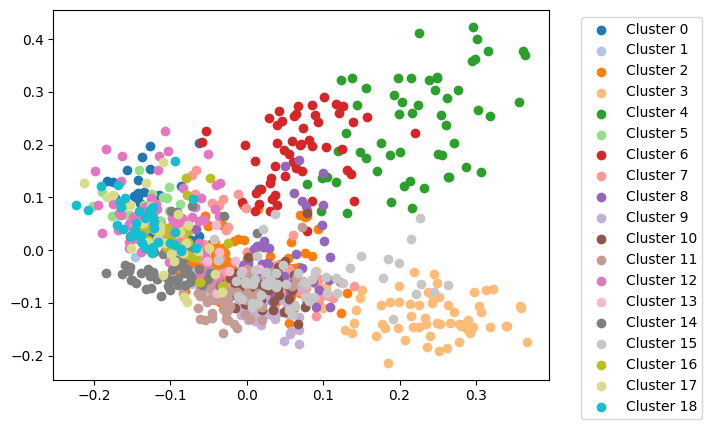

In [120]:

colors = plt.get_cmap('tab20')
cluster_labels = kmeans.labels_

for i in range(num_clusters):
    cluster_points = reduced_symptoms[cluster_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors(i), label=f'Cluster {i}')
#the legend is interfering with the plot, so we will put it outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()